# 监督学习实战：鸢尾花多算法对比

本 Notebook 是 [`笔记/经典ML/监督学习.md`](../笔记/经典ML/监督学习.md) 的实战配套。

**学习目标**：
1. 复现笔记中的最小例子
2. 横向对比多个监督学习算法
3. 用交叉验证评估稳定性
4. 用 GridSearch 调超参
5. 观察过拟合现象（学习曲线）

## 1. 准备工作

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti TC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 算法
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

%matplotlib inline
np.random.seed(42)

## 2. 加载数据并划分训练 / 测试集

In [2]:
X, y = load_iris(return_X_y=True)
target_names = load_iris().target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (120, 4), Test: (30, 4)


## 3. 笔记中的最小例子（基线：逻辑回归）

In [3]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 4. 多算法横向对比

用 **Pipeline** 把标准化和模型打包，避免数据泄漏；用 **5 折交叉验证** 评估每个算法的稳定性。

In [4]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=200),
    'KNN (k=5)':          KNeighborsClassifier(n_neighbors=5),
    'DecisionTree':       DecisionTreeClassifier(random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting':   GradientBoostingClassifier(random_state=42),
    'SVM (RBF)':          SVC(kernel='rbf', gamma='scale'),
    'GaussianNB':         GaussianNB(),
}

results = []
for name, clf in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    pipe.fit(X_train, y_train)
    test_acc = pipe.score(X_test, y_test)
    results.append({
        'model': name,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_acc': test_acc,
    })

df_res = pd.DataFrame(results).sort_values('cv_mean', ascending=False)
df_res

,model,cv_mean,cv_std,test_acc
1,KNN (k=5),0.966667,0.031180,0.933333
5,SVM (RBF),0.966667,0.031180,0.966667
4,GradientBoosting,0.966667,0.016667,0.966667
6,GaussianNB,0.958333,0.026352,0.966667
0,LogisticRegression,0.958333,0.026352,0.933333
3,RandomForest,0.950000,0.016667,0.900000
2,DecisionTree,0.941667,0.020412,0.933333


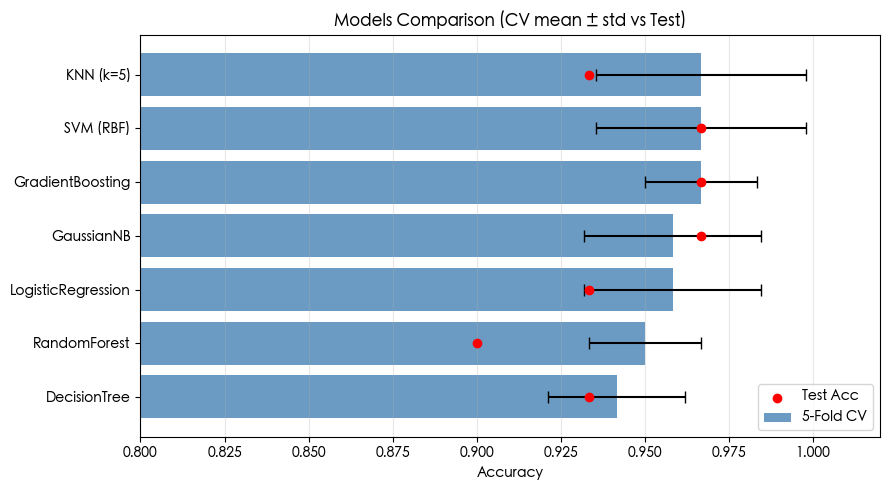

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(df_res['model'], df_res['cv_mean'], xerr=df_res['cv_std'],
        color='steelblue', alpha=0.8, capsize=4, label='5-Fold CV')
ax.scatter(df_res['test_acc'], df_res['model'], color='red', zorder=5, label='Test Acc')
ax.set_xlim(0.8, 1.02); ax.set_xlabel('Accuracy')
ax.set_title('Models Comparison (CV mean ± std vs Test)')
ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

## 5. 用 GridSearch 给随机森林调参

In [6]:
param_grid = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [None, 3, 5, 10],
    'clf__min_samples_split': [2, 5],
}
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])
grid = GridSearchCV(pipe_rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print('Best params:', grid.best_params_)
print('Best CV score:', grid.best_score_)
print('Test accuracy:', grid.score(X_test, y_test))

Best params: {'clf__max_depth': 3, 'clf__min_samples_split': 2, 'clf__n_estimators': 50}
Best CV score: 0.9583333333333334
Test accuracy: 0.9666666666666667


## 6. 学习曲线：观察过拟合 / 欠拟合

- **训练曲线远高于验证曲线** → 过拟合
- **两条曲线都很低且贴近** → 欠拟合
- **两条曲线都高且贴近** → 理想

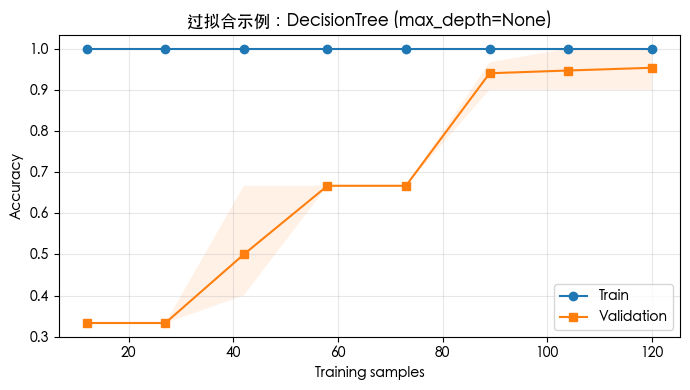

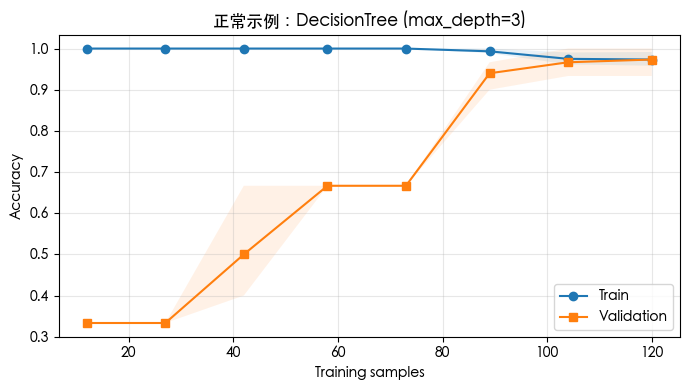

In [7]:
def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8), scoring='accuracy'
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    plt.figure(figsize=(7, 4))
    plt.plot(train_sizes, train_mean, 'o-', label='Train')
    plt.plot(train_sizes, val_mean, 's-', label='Validation')
    plt.fill_between(train_sizes, train_scores.min(axis=1), train_scores.max(axis=1), alpha=0.1)
    plt.fill_between(train_sizes, val_scores.min(axis=1), val_scores.max(axis=1), alpha=0.1)
    plt.xlabel('Training samples'); plt.ylabel('Accuracy')
    plt.title(title); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 故意做一个深度太大的决策树（容易过拟合）
plot_learning_curve(
    Pipeline([('s', StandardScaler()), ('c', DecisionTreeClassifier(max_depth=None, random_state=42))]),
    X, y, '过拟合示例：DecisionTree (max_depth=None)'
)

# 限制深度后看看
plot_learning_curve(
    Pipeline([('s', StandardScaler()), ('c', DecisionTreeClassifier(max_depth=3, random_state=42))]),
    X, y, '正常示例：DecisionTree (max_depth=3)'
)

## 7. 混淆矩阵：看模型把哪一类搞错了

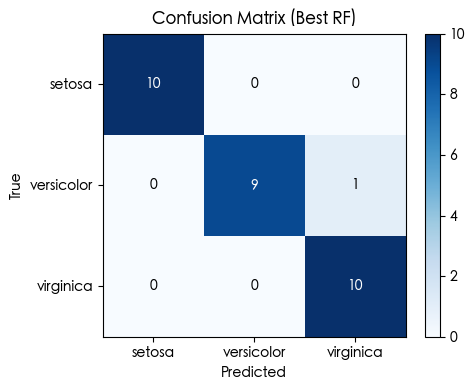

In [8]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(target_names); ax.set_yticklabels(target_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix (Best RF)')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im); plt.tight_layout(); plt.show()

## 8. 特征重要性（树模型独有的可解释性）

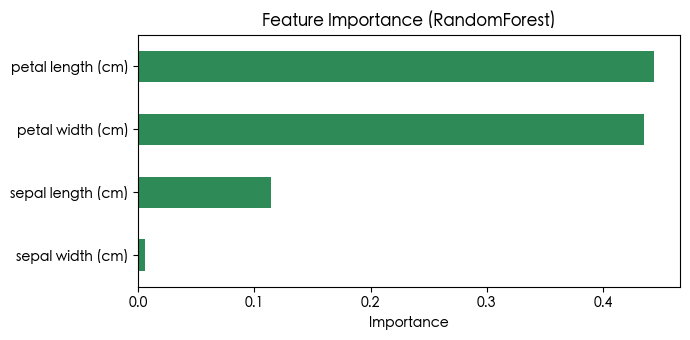

In [9]:
rf = best_model.named_steps['clf']
feat_names = load_iris().feature_names
importances = pd.Series(rf.feature_importances_, index=feat_names).sort_values()

plt.figure(figsize=(7, 3.5))
importances.plot(kind='barh', color='seagreen')
plt.title('Feature Importance (RandomForest)')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()

## 9. 小结

本 Notebook 把监督学习笔记中的概念全部跑了一遍：

| 笔记中的概念 | 对应代码段 |
|------------|-----------|
| 训练/测试集划分 + 分层抽样 | 第 2 节 |
| 多算法对比 | 第 4 节 |
| 交叉验证 | 第 4 节 cross_val_score |
| 超参调优 | 第 5 节 GridSearchCV |
| 过拟合可视化 | 第 6 节学习曲线 |
| 混淆矩阵 / Precision / Recall / F1 | 第 3、7 节 |
| 特征重要性（可解释性） | 第 8 节 |

### 接下来可尝试
- 换数据集：`load_breast_cancer`（二分类）、`load_wine`（多分类）
- 换更难的回归任务：`fetch_california_housing`
- 试试 XGBoost / LightGBM